In [1]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.model_selection import train_test_split
import torch
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

 cupy not imported 


In [2]:
digits = datasets.load_digits()
print(digits.data.shape)
print(digits.images.shape)
print(digits.target.shape)

(1797, 64)
(1797, 8, 8)
(1797,)


In [3]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

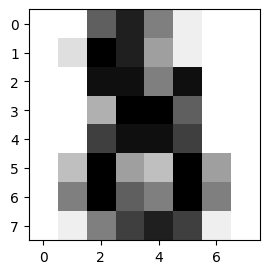

In [3]:
plt.figure(1, figsize=(3, 3))
plt.imshow(digits.images[-1], cmap=plt.cm.gray_r)
plt.show()

In [4]:
num_features = 6
pca = PCA(num_features)
small_data = pca.fit_transform(digits.data)
print(pca.explained_variance_)
print(pca.components_.shape)
print(small_data.shape)

[179.0069301  163.71774688 141.78843909 101.1003752   69.51316559
  59.10852464]
(6, 64)
(1797, 6)


In [5]:
targets = digits.target
targets[targets!=5]=0
targets[targets==5]=1

In [6]:
X_train, X_test, y_train, y_test = train_test_split(small_data, targets, test_size=0.3, random_state=42)

In [7]:
batch_size = 64
testset = TensorDataset(torch.Tensor(X_test),torch.Tensor(y_test)) # create your datset
trainset = TensorDataset(torch.Tensor(X_train),torch.Tensor(y_train)) # create your datset
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

In [8]:
MM=8000

In [9]:
class ShallowClassifier(nn.Module):
    def __init__(self):
        super(ShallowClassifier,self).__init__()
        self.fc1 = nn.Linear(num_features,MM)
        self.fc2 = nn.Linear(MM,1)     
        #self.fc1.weight = torch.nn.Parameter(torch.Tensor(wh.T))
        #self.fc1.bias = torch.nn.Parameter(torch.Tensor(tv*zv))      
        #self.fc2.bias = torch.nn.Parameter(torch.Tensor(np.array([np.mean(y)])))
        #self.fc2.weight = torch.nn.Parameter(torch.Tensor((sne)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [10]:
model = ShallowClassifier()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

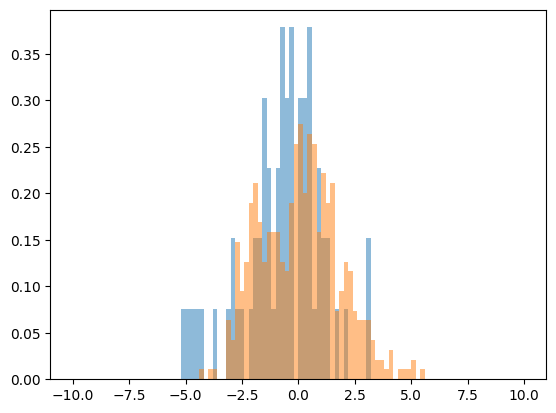

In [11]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-10,10))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-10,10))
plt.show()

In [12]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

tensor(2.4393, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [13]:
for epoch in range(40):  # loop over the dataset multiple times

    running_loss = 0.0
    counter = 0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels.reshape((-1, 1)))
        loss.backward()
        optimizer.step()
        # print statistics
        running_loss += loss.item()
        counter += 1
        #if i % 200 == 199:    # print every 2000 mini-batches
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / counter:.3f}')
    running_loss = 0.0

print('Finished Training')

[1,    20] loss: 2.130
[2,    20] loss: 6.581
[3,    20] loss: 2.733
[4,    20] loss: 2.989
[5,    20] loss: 2.067
[6,    20] loss: 1.656
[7,    20] loss: 1.482
[8,    20] loss: 0.767
[9,    20] loss: 1.615
[10,    20] loss: 2.382
[11,    20] loss: 1.639
[12,    20] loss: 1.698
[13,    20] loss: 0.940
[14,    20] loss: 0.960
[15,    20] loss: 0.650
[16,    20] loss: 0.534
[17,    20] loss: 0.627
[18,    20] loss: 0.464
[19,    20] loss: 0.519
[20,    20] loss: 0.188
[21,    20] loss: 0.553
[22,    20] loss: 1.225
[23,    20] loss: 0.480
[24,    20] loss: 1.146
[25,    20] loss: 0.735
[26,    20] loss: 0.585
[27,    20] loss: 0.823
[28,    20] loss: 0.592
[29,    20] loss: 0.663
[30,    20] loss: 0.992
[31,    20] loss: 0.330
[32,    20] loss: 0.498
[33,    20] loss: 0.421
[34,    20] loss: 0.190
[35,    20] loss: 0.326
[36,    20] loss: 1.394
[37,    20] loss: 0.707
[38,    20] loss: 0.516
[39,    20] loss: 0.251
[40,    20] loss: 0.917
Finished Training


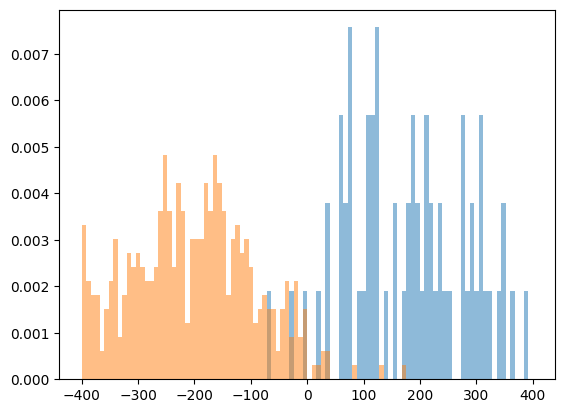

In [14]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-400,400))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-400,400))
plt.show()

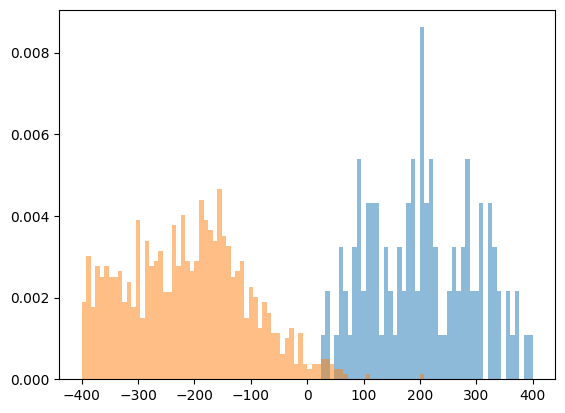

In [15]:
check_output = model(torch.Tensor(X_train))
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-400,400))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-400,400))
plt.show()

In [16]:
y_mod_test=y_test*20-10
y_mod_train=y_train*20-10
print(y_mod_test[:40])
print(y_test[:40])

[-10 -10 -10 -10 -10 -10  10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10 -10 -10 -10 -10  10 -10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10 -10 -10]
[0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0]


In [19]:
print(X_train)
tmin = np.min(X_train,axis=0)
tmax = np.max(X_train,axis=0)
print(tmax,tmin)
fmax=np.ones(6)
fmin=np.ones(6)
fmax[0]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[0]-tmax[0])/100.)))
fmax[1]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[1]-tmax[1])/100.)))
fmax[2]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[2]-tmax[2])/100.)))
fmax[3]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[3]-tmax[3])/100.)))
fmax[4]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[4]-tmax[4])/100.)))
fmax[5]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[5]-tmax[5])/100.)))
fmin[0]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[0]-tmax[0])/100.)))
fmin[1]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[1]-tmax[1])/100.)))
fmin[2]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[2]-tmax[2])/100.)))
fmin[3]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[3]-tmax[3])/100.)))
fmin[4]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[4]-tmax[4])/100.)))
fmin[5]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[5]-tmax[5])/100.)))
print(fmax,fmin)

[[ -5.92532412   8.74788318  -4.85421165  -3.33470705  -4.72924462
   -1.27256366]
 [  1.33728459 -19.62335624 -16.15855958   6.14622567  -8.25175154
    5.92880144]
 [  8.26332546  -5.30485196  24.25510011 -11.29601816   6.0955657
    1.71201161]
 ...
 [-11.79359048 -12.31380841  -0.86659362   2.10434312 -18.17564215
    2.18802648]
 [  5.5076464   -9.54406927 -15.57852195   5.16906632  -2.53615542
    3.72090194]
 [ 14.42434344 -15.63583035  13.49190931  -3.50297847  -5.93589482
   -8.10853572]]
[31.70012528 29.18590721 32.70885483 35.48735557 27.60074737 20.29715566] [-31.16990427 -27.49444714 -29.3017446  -30.45832594 -21.62290828
 -18.15759457]
[0.7952915  0.88213986 0.80631377 0.75819976 1.01577177 1.30022948] [-0.77938567 -0.86449707 -0.79018749 -0.74303577 -0.99545634 -1.27422489]


In [20]:
grid_info = np.array([[fmin[j]/2, fmax[j]/2,9] for j in np.arange(6)])
ycomp = (1/X_train.shape[0])/(np.sqrt(2*np.pi)**2)
calcdft = dft.nu_dft_cupy(X_train, y_mod_train,[0])
yf, f, yfu, yfuc = (calcdft.process_grid(grid_info, 0.0, ycomp, 0))

 Cupy not installed 
 Cupy not installed 


TypeError: cannot unpack non-iterable NoneType object